# InsurPrime: Can You Guess the Insurance Premium?
by Crédit Agricole Assurances

## Model: CatBoost Regressor

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import TweedieRegressor
from catboost import CatBoostRegressor

In [2]:
from feature_eng import add_engineered_features
from data_preprocessing import preprocess_data

## Data Loading

In [3]:
X_train=pd.read_csv("train_input.csv")
y_train=pd.read_csv("train_output.csv")
X_test=pd.read_csv("test_input.csv")

/tmp/ipykernel_205640/3283101309.py:1: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train=pd.read_csv("train_input.csv")
/tmp/ipykernel_205640/3283101309.py:3: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_test=pd.read_csv("test_input.csv")


## Data preprocessing

In [4]:
X_train_clean, y_train_clean, fitted = preprocess_data(
    X_train, 
    y_train, 
    is_train=True
)

X_test_clean, _, _ = preprocess_data(
    X_test, 
    is_train=False,
    fitted_transformers=fitted
)

In [5]:
X_train_clean, y_train_clean, fitted = preprocess_data(
    X_train, 
    y_train, 
    is_train=True
)

X_test_clean, _, _ = preprocess_data(
    X_test, 
    is_train=False,
    fitted_transformers=fitted
)

## Adding Features

In [6]:
# train
X_train_fe, fe_meta = add_engineered_features(X_train_clean, is_train=True)

# test
X_test_fe, _ = add_engineered_features(X_test_clean, is_train=False, feature_meta=fe_meta)

### CatBoost Regressor

In [7]:
## Combine train + test for consistent encoding

n_train = len(X_train_fe)
X_combined = pd.concat([X_train_fe, X_test_fe], axis=0, ignore_index=True)

# categorical columns
cat_cols = X_combined.select_dtypes(include=["object", "category"]).columns.tolist()

# Ordinal encode cat cols
# Cast to string so NaNs become 'nan' and are treated as a level
if len(cat_cols) > 0:
    ord_enc = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )
    X_combined[cat_cols] = ord_enc.fit_transform(X_combined[cat_cols].astype(str)).astype(int)

# everything is numeric
X_train_enc = X_combined.iloc[:n_train].copy()
X_test_enc  = X_combined.iloc[n_train:].copy()

# Indices of categorical features
cat_indices = [X_train_enc.columns.get_loc(c) for c in cat_cols]


## Train/val

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_enc,
    y_train_clean,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

# Exposure (ANNEE_ASSURANCE) as sample_weight and for charge computation
w_tr  = pd.to_numeric(X_tr["ANNEE_ASSURANCE"], errors="coerce").fillna(0).clip(lower=0)
w_val = pd.to_numeric(X_val["ANNEE_ASSURANCE"], errors="coerce").fillna(0).clip(lower=0)

In [ ]:
## frequency model = > Poisson

y_tr_freq = y_tr["FREQ"].astype(float)

# Parameters
params_freq = {
    "min_data_in_leaf": 100,
    "iterations": 500,
    "learning_rate": 0.1,
    "depth": 3,
    "l2_leaf_reg": 5.0,
    "loss_function": "Poisson",
    "verbose": 100,
}

freq_model = CatBoostRegressor(
    **params_freq,
    cat_features=cat_indices,
    random_seed=42
)

freq_model.fit(
    X_tr,
    y_tr["FREQ"].astype(float),
    sample_weight=w_tr,
    eval_set=(X_val, y_val["FREQ"].astype(float)),
    use_best_model=True,
    early_stopping_rounds=100,
)

pred_freq_val = np.clip(freq_model.predict(X_val), 0, None)

0:	learn: 0.6402293	test: 0.6419377	best: 0.6419377 (0)	total: 1.07s	remaining: 8m 53s
100:	learn: 0.0564576	test: 0.0672161	best: 0.0671546 (81)	total: 1m 24s	remaining: 5m 34s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.06715462871
bestIteration = 81

Shrink model to first 82 iterations.


In [9]:
## Severity model => Gamma (approximated by Tweedie:variance_power=1.5 in CatBoost)

mask_claim_tr = y_tr["CHARGE"] > 0
X_tr_sev = X_tr[mask_claim_tr].copy()
y_tr_sev = y_tr.loc[mask_claim_tr, "CM"].astype(float)
y_tr_sev = np.maximum(y_tr_sev, 1.0)  # Tweedie needs y >= 0

params_sev = {
    "min_data_in_leaf": 150,
    "iterations": 1000,
    "learning_rate": 0.01,
    "l2_leaf_reg": 5.0,
    "loss_function": "Tweedie:variance_power=1.5",
    "verbose": 0,
}

sev_model = CatBoostRegressor(
    **params_sev,
    cat_features=cat_indices,
    random_seed=42
)
sev_model.fit(X_tr_sev, y_tr_sev)

pred_sev_val = sev_model.predict(X_val)


In [10]:
# Clip severity
limit_sev_val = y_tr_sev.quantile(0.999) * 2.0
pred_sev_val = np.clip(pred_sev_val, 0, limit_sev_val)


## Val CHARGE and RMSE

pred_charge_val = pred_freq_val * pred_sev_val * w_val

rmse_val = np.sqrt(mean_squared_error(y_val["CHARGE"], pred_charge_val))
print(f"Validation RMSE: {rmse_val:,.2f}")

Validation RMSE: 7,039.21


In [14]:
test_ids = X_test["ID"].copy()
test_exposure = X_test["ANNEE_ASSURANCE"]

In [12]:
## Train on full train and predict on test

print("\n Training ensemble on FULL data and scoring test ")

w_full  = pd.to_numeric(X_train_enc["ANNEE_ASSURANCE"], errors="coerce").fillna(0).clip(lower=0)
y_full_freq = y_train_clean["FREQ"].astype(float)

mask_claim_full = y_train_clean["CHARGE"] > 0
X_full_sev      = X_train_enc[mask_claim_full].copy()
y_full_sev      = y_train_clean.loc[mask_claim_full, "CM"].astype(float)
y_full_sev      = np.maximum(y_full_sev, 1.0)

n_bags = 5
preds_freq_test = np.zeros(len(X_test_enc))
preds_sev_test  = np.zeros(len(X_test_enc))

for i in range(n_bags):
    seed = 42 + i
    print(f"Bag {i+1}/{n_bags}...")

    # Frequency
    model_freq = CatBoostRegressor(
        cat_features=cat_indices, # Changed from categorical_features
        random_seed=seed, # Changed from random_state
        **params_freq
    )
    model_freq.fit(X_train_enc, y_full_freq, sample_weight=w_full)
    preds_freq_test += model_freq.predict(X_test_enc)

    # Severity
    model_sev = CatBoostRegressor(
        cat_features=cat_indices, # Changed from categorical_features
        random_seed=seed, # Changed from random_state
        **params_sev
    )
    model_sev.fit(X_full_sev, y_full_sev)
    preds_sev_test += model_sev.predict(X_test_enc)

# Average the bagged predictions
preds_freq_test /= n_bags
preds_sev_test  /= n_bags

# Clip predictions
preds_freq_test = np.clip(preds_freq_test, 0, None)
limit_sev_full = y_full_sev.quantile(0.999) * 2.0
preds_sev_test = np.clip(preds_sev_test, 0, limit_sev_full)

# Final charge = freq * severity * exposure
test_exposure_clean = pd.to_numeric(test_exposure, errors="coerce").fillna(0).clip(lower=0)
pred_charge_test = preds_freq_test * preds_sev_test * test_exposure_clean.to_numpy(dtype=float)


## submission

submission = pd.DataFrame({
    "ID": test_ids,
    "FREQ": preds_freq_test,
    "CM": preds_sev_test,
    "ANNEE_ASSURANCE": test_exposure_clean,
    "CHARGE": pred_charge_test,
})

os.makedirs("Submissions", exist_ok=True)
submission.to_csv("Submissions/submission_catboost.csv", index=False)
print("\nSaved submission_catboost.csv")
print(submission.head())


 Training ensemble on FULL data and scoring test 
Bag 1/5...
0:	learn: 0.6421868	total: 1.28s	remaining: 10m 40s
100:	learn: 0.0560879	total: 1m 38s	remaining: 6m 27s
200:	learn: 0.0557772	total: 3m 9s	remaining: 4m 42s
300:	learn: 0.0554148	total: 4m 43s	remaining: 3m 7s
400:	learn: 0.0550782	total: 6m 18s	remaining: 1m 33s
499:	learn: 0.0548419	total: 7m 51s	remaining: 0us
Bag 2/5...
0:	learn: 0.6427675	total: 1.09s	remaining: 9m 4s
100:	learn: 0.0561414	total: 1m 33s	remaining: 6m 7s
200:	learn: 0.0557876	total: 3m 3s	remaining: 4m 33s
300:	learn: 0.0555161	total: 4m 35s	remaining: 3m 2s
400:	learn: 0.0552125	total: 6m 7s	remaining: 1m 30s
499:	learn: 0.0548998	total: 7m 37s	remaining: 0us
Bag 3/5...
0:	learn: 0.6402119	total: 1.21s	remaining: 10m 5s
100:	learn: 0.0562150	total: 1m 32s	remaining: 6m 5s
200:	learn: 0.0559057	total: 3m 3s	remaining: 4m 32s
300:	learn: 0.0555429	total: 4m 33s	remaining: 3m 1s
400:	learn: 0.0551875	total: 6m 7s	remaining: 1m 30s
499:	learn: 0.0549374	t

We observe that the validation RMSE is quite high (RMSE = 7039.21) which is much bigger than the benchmark RMSE = 5617.62. However, we get a much better RMSE on the test dataset : RMSE = 5598.75. 

The high validation RMSE probably arises from random variation from a few large claims falling into the validation split, which makes the metric very unstable in rare-event, heavy-tailed data.
The test RMSE is much lower and beats the benchmark, meaning the model actually generalizes well and is performing strongly.

### Useful graphs to understand the model

In [13]:
df_val = pd.DataFrame({
    "charge_true": y_val["CHARGE"].values,
    "charge_pred": pred_charge_val,
    "freq_pred":   pred_freq_val,
    "sev_pred":    pred_sev_val,
    "exposure":    w_val.values,
})

# Derived columns
df_val["has_claim"]   = (df_val["charge_true"] > 0).astype(int)
df_val["sev_true"]    = np.where(df_val["has_claim"] == 1,
                                 df_val["charge_true"] / df_val["exposure"].replace(0, np.nan),
                                 np.nan)
df_val["log_true"]    = np.log1p(df_val["charge_true"])
df_val["log_pred"]    = np.log1p(df_val["charge_pred"])
df_val["log_resid"]   = df_val["log_true"] - df_val["log_pred"]

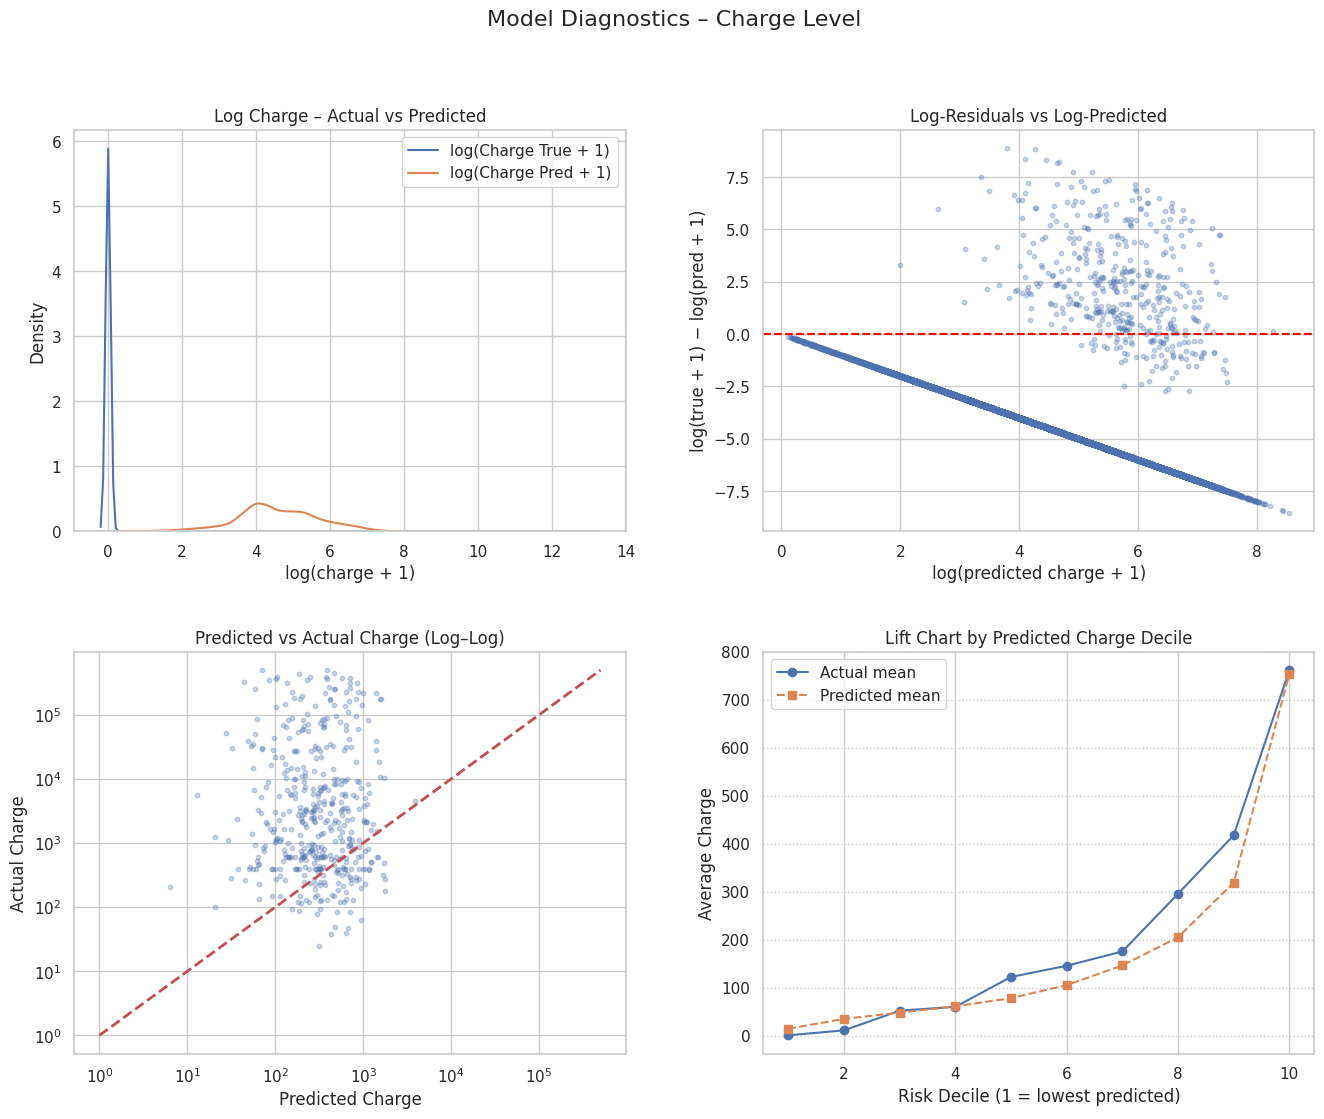

In [14]:
## CHARGE

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Model Diagnostics – Charge Level", fontsize=16)
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# (1,1) Log(actual) vs Log(pred) densities
ax = axes[0, 0]
sns.kdeplot(df_val["log_true"], label="log(Charge True + 1)", ax=ax)
sns.kdeplot(df_val["log_pred"], label="log(Charge Pred + 1)", ax=ax)
ax.set_title("Log Charge – Actual vs Predicted")
ax.set_xlabel("log(charge + 1)")
ax.legend()

# (1,2) Log-residuals vs log-predicted
ax = axes[0, 1]
ax.scatter(df_val["log_pred"], df_val["log_resid"], alpha=0.3, s=10)
ax.axhline(0, color="red", linestyle="--")
ax.set_title("Log-Residuals vs Log-Predicted")
ax.set_xlabel("log(predicted charge + 1)")
ax.set_ylabel("log(true + 1) − log(pred + 1)")

# (2,1) Predicted vs Actual charge (log–log)
ax = axes[1, 0]
mask_pos = df_val["charge_true"] > 0
ax.scatter(df_val.loc[mask_pos, "charge_pred"],
           df_val.loc[mask_pos, "charge_true"],
           alpha=0.3, s=10)
max_val = max(df_val["charge_pred"].max(), df_val["charge_true"].max())
ax.plot([1, max_val], [1, max_val], "r--", linewidth=2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Predicted vs Actual Charge (Log–Log)")
ax.set_xlabel("Predicted Charge")
ax.set_ylabel("Actual Charge")

# (2,2) Decile lift chart
ax = axes[1, 1]
# Rank by predicted charge and split into 10 groups
df_val_sorted = df_val.sort_values("charge_pred").reset_index(drop=True)
df_val_sorted["decile"] = pd.qcut(
    df_val_sorted.index,
    q=10,
    labels=False
)

decile_stats = df_val_sorted.groupby("decile")[["charge_true", "charge_pred"]].mean()
x = np.arange(1, 11)

ax.plot(x, decile_stats["charge_true"], marker="o", label="Actual mean")
ax.plot(x, decile_stats["charge_pred"], marker="s", linestyle="--", label="Predicted mean")
ax.set_title("Lift Chart by Predicted Charge Decile")
ax.set_xlabel("Risk Decile (1 = lowest predicted)")
ax.set_ylabel("Average Charge")
ax.legend()
ax.grid(axis="y", linestyle=":")

plt.show()

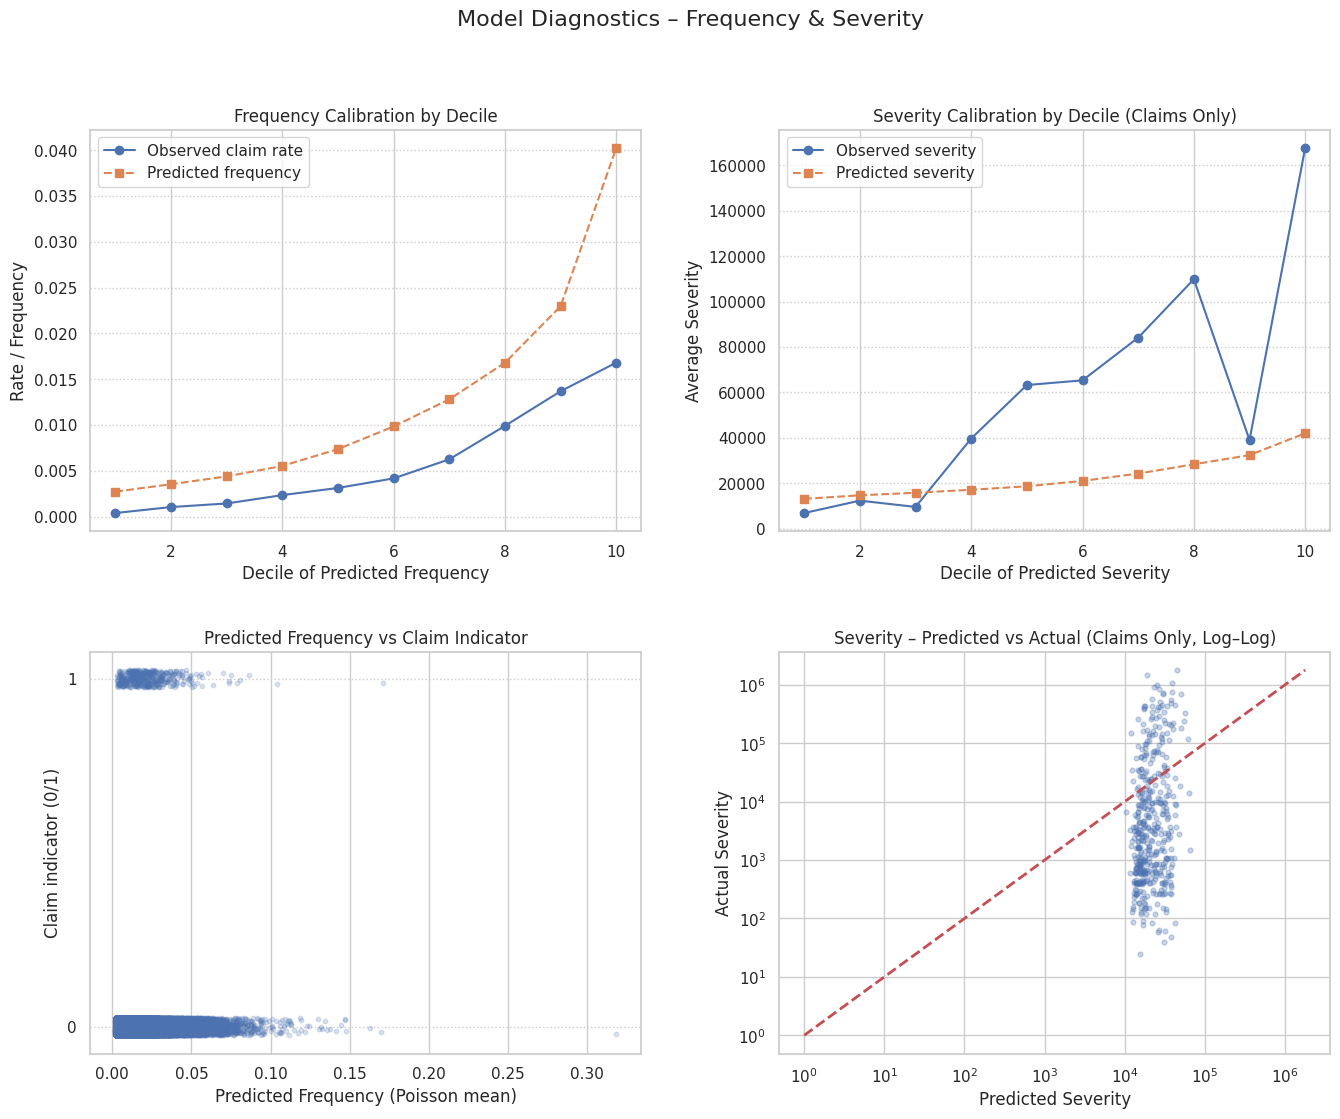

In [15]:
## FREQUENCY & SEVERITY

fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle("Model Diagnostics – Frequency & Severity", fontsize=16)
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# (1,1) Frequency calibration by decile
ax = axes2[0, 0]

df_freq = df_val.copy()
df_freq_sorted = df_freq.sort_values("freq_pred").reset_index(drop=True)
df_freq_sorted["decile"] = pd.qcut(
    df_freq_sorted.index,
    q=10,
    labels=False
)

# Observed frequency = mean(has_claim) / mean(exposure)? or just mean(has_claim)
# Here: observed claim probability per decile
freq_stats = df_freq_sorted.groupby("decile").agg(
    obs_rate=("has_claim", "mean"),
    pred_rate=("freq_pred", "mean"),
)

x = np.arange(1, 11)
ax.plot(x, freq_stats["obs_rate"], marker="o", label="Observed claim rate")
ax.plot(x, freq_stats["pred_rate"], marker="s", linestyle="--", label="Predicted frequency")
ax.set_title("Frequency Calibration by Decile")
ax.set_xlabel("Decile of Predicted Frequency")
ax.set_ylabel("Rate / Frequency")
ax.legend()
ax.grid(axis="y", linestyle=":")

# (1,2) Severity calibration by decile (claims only)
ax = axes2[0, 1]

df_sev = df_val[df_val["has_claim"] == 1].copy()
# Guard against empty
if len(df_sev) > 0:
    df_sev_sorted = df_sev.sort_values("sev_pred").reset_index(drop=True)
    df_sev_sorted["decile"] = pd.qcut(
        df_sev_sorted.index,
        q=10,
        labels=False
    )

    sev_stats = df_sev_sorted.groupby("decile").agg(
        obs_sev=("sev_true", "mean"),
        pred_sev=("sev_pred", "mean"),
    )

    x = np.arange(1, 11)
    ax.plot(x, sev_stats["obs_sev"], marker="o", label="Observed severity")
    ax.plot(x, sev_stats["pred_sev"], marker="s", linestyle="--", label="Predicted severity")
    ax.set_title("Severity Calibration by Decile (Claims Only)")
    ax.set_xlabel("Decile of Predicted Severity")
    ax.set_ylabel("Average Severity")
    ax.legend()
    ax.grid(axis="y", linestyle=":")
else:
    ax.text(0.5, 0.5, "No positive claims in validation set",
            ha="center", va="center")
    ax.set_axis_off()

# (2,1) Predicted frequency vs observed claim indicator
ax = axes2[1, 0]

jitter = (np.random.rand(len(df_val)) - 0.5) * 0.05
ax.scatter(df_val["freq_pred"], df_val["has_claim"] + jitter,
           alpha=0.2, s=10)
ax.set_title("Predicted Frequency vs Claim Indicator")
ax.set_xlabel("Predicted Frequency (Poisson mean)")
ax.set_ylabel("Claim indicator (0/1)")
ax.set_yticks([0, 1])
ax.grid(axis="y", linestyle=":")

# (2,2) Severity scatter (claims only, log–log) ===
ax = axes2[1, 1]
if len(df_sev) > 0:
    ax.scatter(df_sev["sev_pred"], df_sev["sev_true"],
               alpha=0.3, s=12)
    max_sev_val = max(df_sev["sev_pred"].max(), df_sev["sev_true"].max())
    ax.plot([1, max_sev_val], [1, max_sev_val], "r--", linewidth=2)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title("Severity – Predicted vs Actual (Claims Only, Log–Log)")
    ax.set_xlabel("Predicted Severity")
    ax.set_ylabel("Actual Severity")
else:
    ax.text(0.5, 0.5, "No positive claims in validation set",
            ha="center", va="center")
    ax.set_axis_off()

plt.show()

## Hyperparameters tuning 

In [8]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

In [9]:
# 1. Modèle de base SANS cat_features
severity_model = CatBoostRegressor(
    iterations=600, 
    learning_rate=0.05,
    loss_function='Tweedie:variance_power=1.5',
    random_seed=42,
    verbose=0,
    thread_count=-1
)

# 2. Ta grille de paramètres
severity_param_grid = {
    
    'l2_leaf_reg': [0.5, 1.0, 3.0],
    'loss_function': [
        'Tweedie:variance_power=1.5', 
        'Tweedie:variance_power=1.7', 
        'Tweedie:variance_power=1.9'
    ]
}

# 3. GridSearchCV (n_jobs=1 pour éviter le crash mémoire)
severity_grid_search = GridSearchCV(
    estimator=severity_model,
    param_grid=severity_param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=1 
)

# 4. LE FIX : Passer cat_features ici
# On entraîne uniquement sur les sinistres (CHARGE > 0)
mask_claims = y_tr["CHARGE"] > 0
X_sev_train = X_tr[mask_claims]
y_sev_train = y_tr.loc[mask_claims, "CM"].astype(float)

print("Lancement du tuning...")
severity_grid_search.fit(
    X_sev_train, 
    y_sev_train,
    cat_features=cat_indices  # On le met ici, et non plus haut !
)

print("Meilleurs paramètres :", severity_grid_search.best_params_)

Lancement du tuning...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Meilleurs paramètres : {'l2_leaf_reg': 0.5, 'loss_function': 'Tweedie:variance_power=1.9'}


In [10]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor

# 1. Modèle de base "propre" (sans cat_features)
# On utilise Poisson car on modélise un comptage de sinistres
frequency_model = CatBoostRegressor(
    iterations=500,
    loss_function='Poisson', # Crucial pour la fréquence
    random_seed=42,
    verbose=0,
    thread_count=-1
)

# 2. Grille de paramètres pour la fréquence
frequency_param_grid = {
    'l2_leaf_reg': [5, 7, 10],
    
   
}

# 3. Configuration du GridSearchCV
# n_jobs=1 est maintenu pour éviter la saturation de la RAM
frequency_grid_search = GridSearchCV(
    estimator=frequency_model,
    param_grid=frequency_param_grid,
    cv=3,
    scoring='neg_mean_poisson_deviance', # Meilleur scoring pour la loi de Poisson
    verbose=1,
    n_jobs=1 
)

# 4. Exécution du Tuning
print("Lancement du tuning des fréquences...")

# Rappel : Pour la fréquence, on utilise TOUT le dataset d'entraînement
# et on pondère par l'exposition (w_tr)
frequency_grid_search.fit(
    X_tr, 
    y_tr["FREQ"].astype(float), 
    sample_weight=w_tr,      # Indispensable pour la fréquence
    cat_features=cat_indices  # Le fix est ici !
)

print("\n--- Meilleurs paramètres Fréquence ---")
print(frequency_grid_search.best_params_)

Lancement du tuning des fréquences...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

--- Meilleurs paramètres Fréquence ---
{'l2_leaf_reg': 10}


### Performance of the tuned model

In [11]:
## frequency model = > Poisson

y_tr_freq = y_tr["FREQ"].astype(float)

# Parameters
params_freq = {
    "min_data_in_leaf": 100,
    "iterations": 500,
    "learning_rate": 0.1,
    "depth": 3,
    "l2_leaf_reg": 10,
    "loss_function": "Poisson",
    "verbose": 100,
}

freq_model = CatBoostRegressor(
    **params_freq,
    cat_features=cat_indices,
    random_seed=42
)

freq_model.fit(
    X_tr,
    y_tr["FREQ"].astype(float),
    sample_weight=w_tr,
    eval_set=(X_val, y_val["FREQ"].astype(float)),
    use_best_model=True,
    early_stopping_rounds=100,
)

pred_freq_val = np.clip(freq_model.predict(X_val), 0, None)

0:	learn: 0.6402388	test: 0.6419418	best: 0.6419418 (0)	total: 970ms	remaining: 8m 4s
100:	learn: 0.0564556	test: 0.0675775	best: 0.0675630 (84)	total: 1m 12s	remaining: 4m 44s
200:	learn: 0.0559415	test: 0.0678271	best: 0.0675208 (166)	total: 2m 22s	remaining: 3m 31s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.06752077018
bestIteration = 166

Shrink model to first 167 iterations.


In [12]:
## Severity model => Gamma (approximated by Tweedie:variance_power=1.5 in CatBoost)

mask_claim_tr = y_tr["CHARGE"] > 0
X_tr_sev = X_tr[mask_claim_tr].copy()
y_tr_sev = y_tr.loc[mask_claim_tr, "CM"].astype(float)
y_tr_sev = np.maximum(y_tr_sev, 1.0)  # Tweedie needs y >= 0

params_sev = {
    "min_data_in_leaf": 150,
    "iterations": 1000,
    "learning_rate": 0.01,
    "l2_leaf_reg": 0.5,
    "loss_function": "Tweedie:variance_power=1.9",
    "verbose": 0,
}

sev_model = CatBoostRegressor(
    **params_sev,
    cat_features=cat_indices,
    random_seed=42
)
sev_model.fit(X_tr_sev, y_tr_sev)

pred_sev_val = sev_model.predict(X_val)


In [13]:
# Clip severity
limit_sev_val = y_tr_sev.quantile(0.999) * 2.0
pred_sev_val = np.clip(pred_sev_val, 0, limit_sev_val)


## Val CHARGE and RMSE

pred_charge_val = pred_freq_val * pred_sev_val * w_val

rmse_val = np.sqrt(mean_squared_error(y_val["CHARGE"], pred_charge_val))
print(f"Validation RMSE: {rmse_val:,.2f}")

Validation RMSE: 7,040.33


In [15]:
## Train on full train and predict on test

print("\n Training ensemble on FULL data and scoring test ")

w_full  = pd.to_numeric(X_train_enc["ANNEE_ASSURANCE"], errors="coerce").fillna(0).clip(lower=0)
y_full_freq = y_train_clean["FREQ"].astype(float)

mask_claim_full = y_train_clean["CHARGE"] > 0
X_full_sev      = X_train_enc[mask_claim_full].copy()
y_full_sev      = y_train_clean.loc[mask_claim_full, "CM"].astype(float)
y_full_sev      = np.maximum(y_full_sev, 1.0)

n_bags = 5
preds_freq_test = np.zeros(len(X_test_enc))
preds_sev_test  = np.zeros(len(X_test_enc))

for i in range(n_bags):
    seed = 42 + i
    print(f"Bag {i+1}/{n_bags}...")

    # Frequency
    model_freq = CatBoostRegressor(
        cat_features=cat_indices, # Changed from categorical_features
        random_seed=seed, # Changed from random_state
        **params_freq
    )
    model_freq.fit(X_train_enc, y_full_freq, sample_weight=w_full)
    preds_freq_test += model_freq.predict(X_test_enc)

    # Severity
    model_sev = CatBoostRegressor(
        cat_features=cat_indices, # Changed from categorical_features
        random_seed=seed, # Changed from random_state
        **params_sev
    )
    model_sev.fit(X_full_sev, y_full_sev)
    preds_sev_test += model_sev.predict(X_test_enc)

# Average the bagged predictions
preds_freq_test /= n_bags
preds_sev_test  /= n_bags

# Clip predictions
preds_freq_test = np.clip(preds_freq_test, 0, None)
limit_sev_full = y_full_sev.quantile(0.999) * 2.0
preds_sev_test = np.clip(preds_sev_test, 0, limit_sev_full)

# Final charge = freq * severity * exposure
test_exposure_clean = pd.to_numeric(test_exposure, errors="coerce").fillna(0).clip(lower=0)
pred_charge_test = preds_freq_test * preds_sev_test * test_exposure_clean.to_numpy(dtype=float)


## submission

submission = pd.DataFrame({
    "ID": test_ids,
    "FREQ": preds_freq_test,
    "CM": preds_sev_test,
    "ANNEE_ASSURANCE": test_exposure_clean,
    "CHARGE": pred_charge_test,
})

os.makedirs("Submissions", exist_ok=True)
submission.to_csv("Submissions/submission_catboost.csv", index=False)
print("\nSaved submission_catboost.csv")
print(submission.head())


 Training ensemble on FULL data and scoring test 
Bag 1/5...
0:	learn: 0.6421893	total: 1.06s	remaining: 8m 48s
100:	learn: 0.0561033	total: 1m 18s	remaining: 5m 9s
200:	learn: 0.0558716	total: 2m 36s	remaining: 3m 53s
300:	learn: 0.0556527	total: 3m 55s	remaining: 2m 35s
400:	learn: 0.0553948	total: 5m 14s	remaining: 1m 17s
499:	learn: 0.0550674	total: 6m 33s	remaining: 0us
Bag 2/5...
0:	learn: 0.6427765	total: 1.03s	remaining: 8m 35s
100:	learn: 0.0561128	total: 1m 20s	remaining: 5m 17s
200:	learn: 0.0558526	total: 2m 39s	remaining: 3m 57s
300:	learn: 0.0556618	total: 3m 58s	remaining: 2m 37s
400:	learn: 0.0554638	total: 5m 17s	remaining: 1m 18s
499:	learn: 0.0551806	total: 6m 35s	remaining: 0us
Bag 3/5...
0:	learn: 0.6402179	total: 1.05s	remaining: 8m 43s
100:	learn: 0.0563030	total: 1m 19s	remaining: 5m 12s
200:	learn: 0.0560370	total: 2m 31s	remaining: 3m 45s
300:	learn: 0.0558362	total: 3m 47s	remaining: 2m 30s
400:	learn: 0.0555533	total: 5m 5s	remaining: 1m 15s
499:	learn: 0.0